# Statistics Basics

This notebook is a short reference for **displaying/describing quantitative data** and **summarizing quantitative data**.

Goal:
- Know which plot to use for which kind of data.
- Understand common statistics terms like mean, median, standard deviation, quartiles, IQR, outliers, skewness, variance, percentiles, z-score, etc.
- Practice with simple visualizations using `pandas`, `seaborn`, and `matplotlib`.

> Note: Seaborn is used for most plots. For a true stem plot, matplotlib is used because seaborn does not have a direct `stem()` plot function.


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Small example dataset: exam scores and study hours
df = pd.DataFrame({
    "student": [f"S{i}" for i in range(1, 16)],
    "score": [45, 50, 52, 55, 58, 60, 63, 65, 66, 70, 72, 75, 80, 85, 98],
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 8, 10],
    "class_group": ["A", "A", "A", "A", "A", "B", "B", "B", "B", "B", "C", "C", "C", "C", "C"]
})

df

,student,score,study_hours,class_group
0,S1,45,1,A
1,S2,50,2,A
2,S3,52,2,A
3,S4,55,3,A
4,S5,58,3,A
5,S6,60,4,B
6,S7,63,4,B
7,S8,65,4,B
8,S9,66,5,B
9,S10,70,5,B


# Part A — Displaying / Describing Quantitative Data

Quantitative data = numerical data.

Examples:
- stock price
- salary
- exam score
- age
- house price
- sales amount
- temperature


## 2. Histogram

**Meaning:** Shows the distribution of one numerical variable by grouping values into bins.

**Used for:**
- seeing the shape of data
- checking if data is symmetric or skewed
- seeing common value ranges
- finding possible outliers

**Real-world examples:**
- distribution of salaries
- distribution of house prices
- distribution of stock returns
- distribution of exam scores


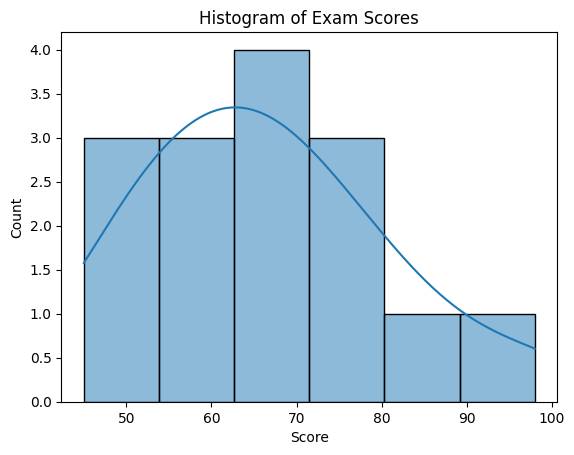

In [5]:
sns.histplot(data=df, x="score", bins=6, kde=True)
plt.title("Histogram of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

## 3. Box Plot

**Meaning:** Shows median, quartiles, spread, and possible outliers.

**Used for:**
- quickly comparing distributions between groups
- spotting outliers
- seeing spread and center

**Real-world examples:**
- salaries by department
- house prices by neighborhood
- sales by region
- exam scores by class


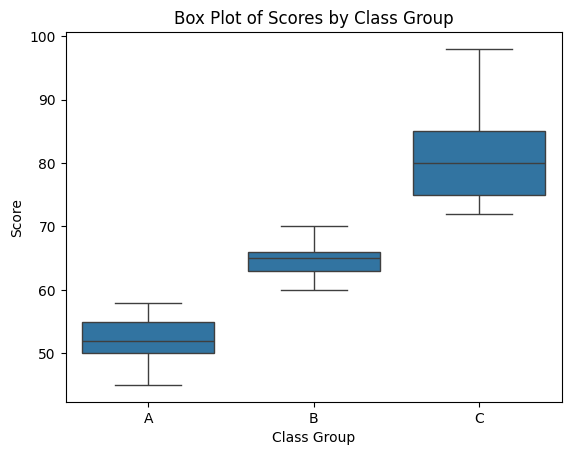

In [6]:
sns.boxplot(data=df, x="class_group", y="score")
plt.title("Box Plot of Scores by Class Group")
plt.xlabel("Class Group")
plt.ylabel("Score")
plt.show()

## 4. Dot Plot / Strip Plot

**Meaning:** Shows each individual data point.

**Used for:**
- small/medium datasets
- seeing exact observations
- comparing groups without hiding individual values

**Real-world examples:**
- scores of students in different classes
- transaction amounts by customer group
- product ratings by category


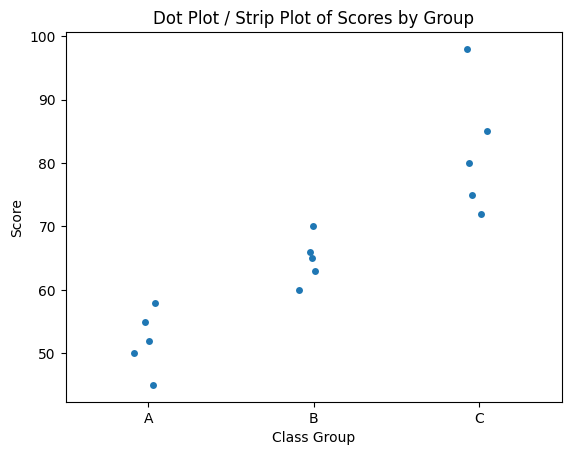

In [9]:
sns.stripplot(data=df, x="class_group", y="score", jitter=True)
plt.title("Dot Plot / Strip Plot of Scores by Group")
plt.xlabel("Class Group")
plt.ylabel("Score")
plt.show()

## 5. Stem Plot

**Meaning:** Shows each value as a vertical line from a baseline.

**Used for:**
- showing discrete ordered values
- small numerical sequences
- time/order-based values

**Real-world examples:**
- daily sales for a small time window
- values by index/order
- signal-like numerical values

> Seaborn does not have a direct stem plot function, so matplotlib is used here.


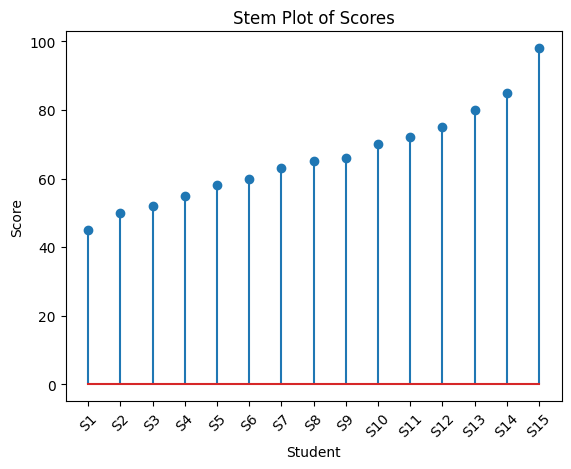

In [10]:
plt.stem(df["student"], df["score"])
plt.title("Stem Plot of Scores")
plt.xlabel("Student")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

## 6. Scatter Plot

**Meaning:** Shows relationship between two numerical variables.

**Used for:**
- checking if two variables move together
- seeing positive/negative/no relationship
- finding outliers

**Real-world examples:**
- study hours vs exam score
- advertising spend vs sales
- house size vs house price
- risk vs return in finance


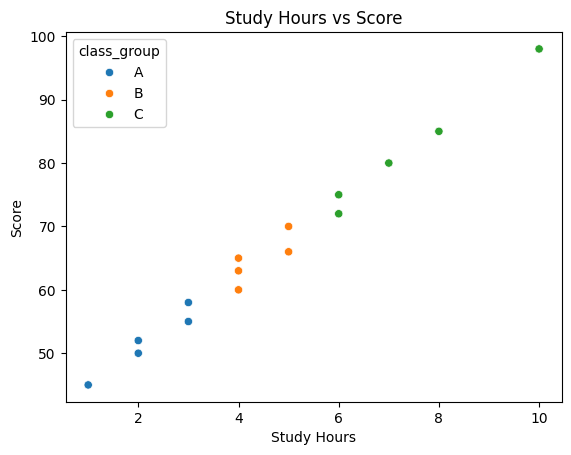

In [11]:
sns.scatterplot(data=df, x="study_hours", y="score", hue="class_group")
plt.title("Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

## 7. Line Plot

**Meaning:** Shows change over order or time.

**Used for:**
- time series
- trends
- growth/decline patterns

**Real-world examples:**
- stock price over time
- monthly revenue
- website traffic per day
- inflation rate over years


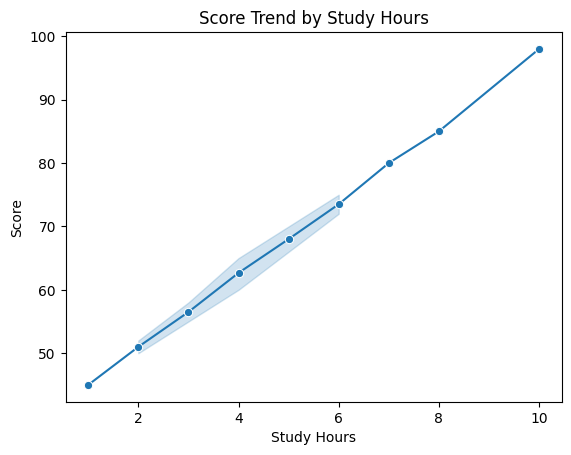

In [15]:
sns.lineplot(data=df, x="study_hours", y="score", marker="o")
plt.title("Score Trend by Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

## 8. Violin Plot

**Meaning:** Similar to box plot, but also shows distribution shape.

**Used for:**
- comparing groups
- seeing both spread and density
- when box plot feels too limited

**Real-world examples:**
- salary distributions by job title
- customer spending by segment
- delivery times by city


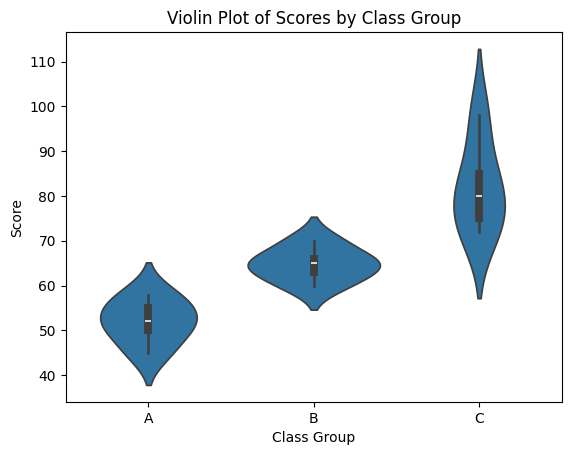

In [16]:
sns.violinplot(data=df, x="class_group", y="score")
plt.title("Violin Plot of Scores by Class Group")
plt.xlabel("Class Group")
plt.ylabel("Score")
plt.show()

# Part B — Summarizing Quantitative Data

This section explains common statistics terms shortly.

Most used in real-world data work:
- mean
- median
- standard deviation
- variance
- percentiles
- quartiles
- IQR
- outliers
- correlation
- skewness
- z-score


## 9. Core Statistics Terms

## Symbols Used in This Section

| Symbol | Meaning |
|---|---|
| $x_i$ | One individual data value |
| $x_1, x_2, ..., x_n$ | All data values in a sample |
| $n$ | Number of values in a sample |
| $N$ | Number of values in a population |
| $\bar{x}$ | Sample mean |
| $\mu$ | Population mean |
| $s^2$ | Sample variance |
| $\sigma^2$ | Population variance |
| $s$ | Sample standard deviation |
| $\sigma$ | Population standard deviation |
| $Q1$ | First quartile, 25th percentile |
| $Q2$ | Second quartile, median, 50th percentile |
| $Q3$ | Third quartile, 75th percentile |
| $IQR$ | Interquartile range |
| $r$ | Correlation coefficient |
| $z$ | Z-score |
| $w_i$ | Weight of a value |
| $p$ | Probability |
| $SE$ | Standard error |
| $CV$ | Coefficient of variation |

### Population vs Sample Notation

Use **population formulas** when the dataset contains the whole group you care about.

Use **sample formulas** when the dataset is only a smaller part of a larger group.

Example:

- Population: exam scores of every student in one class
- Sample: exam scores of 10 students selected from the whole school

### Mean

**Meaning:** Average value.

**Formula:**  
$$
\bar{x} = \frac{x_1 + x_2 + \cdots + x_n}{n}
$$

**Example:**  
For `[10, 20, 30]`, mean = `20`.

**Used when:**  
Data is fairly balanced and has no extreme outliers.

**Very common in real world:** Yes. Used in finance, business, ML, reporting.


### Median

**Meaning:** Middle value after sorting.

**Formula:**  
No single formula for all cases. Sort the values and choose the middle.

**Example:**  
For `[10, 20, 1000]`, median = `20`.

**Used when:**  
Data has outliers or is skewed.

**Very common in real world:** Yes. Often used for income, house prices, salaries.


### Mode

**Meaning:** Most frequent value.

**Example:**  
For `[1, 2, 2, 3]`, mode = `2`.

**Used when:**  
You want the most common category/value.

**Very common in real world:** Common for categorical data, less useful for continuous numerical data.


### Range

**Meaning:** Difference between maximum and minimum.

**Formula:**  
$$
Range = Max - Min
$$

**Example:**  
For `[10, 20, 30]`, range = `30 - 10 = 20`.

**Used when:**  
You want a quick idea of total spread.

**Problem:**  
Very sensitive to outliers.


### Variance

**Meaning:** Average squared distance from the mean.

**Population formula:**  
$$
\sigma^2 = \frac{\sum (x_i - \mu)^2}{N}
$$

**Sample formula:**  
$$
s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}
$$

**Example:**  
If values are far from the mean, variance is large.

**Used when:**  
You need a mathematical measure of spread. Important in statistics and ML.

**Very common in real world:** Used often internally, but standard deviation is easier to interpret.


### Standard Deviation

**Meaning:** Typical distance from the mean.

**Formula:**  
$$
s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n-1}}
$$

**Example:**  
Low standard deviation = values are close together.  
High standard deviation = values are spread out.

**Used when:**  
You want to understand volatility, risk, or spread.

**Very common in real world:** Yes. Very important in finance, ML, quality control.


### Quartiles

**Meaning:** Values that split sorted data into four parts.

- Q1 = 25th percentile
- Q2 = 50th percentile = median
- Q3 = 75th percentile

**Used when:**  
You want to understand spread without being too affected by outliers.

**Very common in real world:** Yes, especially in box plots.


### IQR — Interquartile Range

**Meaning:** Middle 50% spread of the data.

**Formula:**  
$$
IQR = Q3 - Q1
$$

**Example:**  
If Q1 = 20 and Q3 = 50, IQR = 30.

**Used when:**  
Data has outliers or skewness.

**Very common in real world:** Yes. Used for outlier detection.


### Percentile

**Meaning:** Shows the value below which a percentage of data falls.

**Example:**  
90th percentile means 90% of values are below this value.

**Used when:**  
You want ranking or threshold information.

**Very common in real world:** Yes. Used in exams, salaries, latency, risk, finance.


### Outlier

**Meaning:** A value unusually far from the rest.

**Common rule:**  
$$
Lower = Q1 - 1.5 \times IQR
$$
$$
Upper = Q3 + 1.5 \times IQR
$$

**Used when:**  
Cleaning data, detecting fraud, finding unusual behavior.

**Very common in real world:** Yes. Very important in data analysis.


### Skewness

**Meaning:** Shows whether a distribution has a long tail.

- Right-skewed: long tail to the right
- Left-skewed: long tail to the left
- Symmetric: balanced shape

**Example:**  
Income is usually right-skewed because a few people earn extremely high income.

**Used when:**  
Choosing mean vs median and understanding distribution shape.

**Very common in real world:** Yes.


### Correlation

**Meaning:** Measures how two numerical variables move together.

**Range:**  
$$
-1 \le r \le 1
$$

- `r > 0`: positive relationship
- `r < 0`: negative relationship
- `r ≈ 0`: weak/no linear relationship

**Example:**  
Study hours and exam score may have positive correlation.

**Used when:**  
Exploring relationships between variables.

**Very common in real world:** Yes. But correlation does not prove causation.


### Covariance

**Meaning:** Shows whether two variables move together.

**Used when:**  
More mathematical version of relationship direction.

**Problem:**  
Harder to interpret than correlation because it depends on units.

**Real-world use:**  
Used in finance, portfolio theory, statistics, ML.


### Z-score

**Meaning:** How many standard deviations a value is from the mean.

**Formula:**  
$$
z = \frac{x - \mu}{\sigma}
$$

**Example:**  
z = 2 means the value is 2 standard deviations above the mean.

**Used when:**  
Comparing values from different scales or detecting unusual values.

**Very common in real world:** Yes, especially in statistics, finance, ML.


### Coefficient of Variation

**Meaning:** Standard deviation relative to the mean.

**Formula:**  
$$
CV = \frac{s}{\bar{x}}
$$

**Used when:**  
Comparing variability between datasets with different units/scales.

**Real-world example:**  
Comparing risk per expected return in finance.


### Five-number summary

**Meaning:** A compact summary of distribution.

Includes:
- minimum
- Q1
- median
- Q3
- maximum

**Used when:**  
Creating/understanding box plots.

**Very common in real world:** Yes.


### Distribution

**Meaning:** Shows how values are spread.

Important features:
- center
- spread
- shape
- outliers

**Used when:**  
Understanding the behavior of a variable before modeling.

**Very common in real world:** Yes. One of the most important ideas in data analysis.


### Density

**Meaning:** Smoothed version of distribution.

**Used when:**  
You want a smoother shape than histogram bars.

**Real-world use:**  
Data exploration, comparing groups, probability intuition.


### Standard Error

**Meaning:** Measures how much a sample statistic, usually the mean, would vary between samples.

**Formula:**  
$$
SE = \frac{s}{\sqrt{n}}
$$

**Used when:**  
Making confidence intervals and statistical inference.

**More advanced but important:** Yes, especially in statistics and research.


### Confidence Interval

**Meaning:** A range that estimates where a population parameter may be.

**Example:**  
Mean salary is estimated as 40,000–45,000.

**Used when:**  
You want uncertainty around an estimate.

**Real-world use:**  
Surveys, experiments, business estimates, A/B tests.


### Normal Distribution

**Meaning:** Bell-shaped distribution.

**Used when:**  
Many statistical methods assume or approximate normality.

**Real-world use:**  
Measurement errors, standardized tests, many natural processes.

**Important note:**  
Not all data is normal. Income and house prices are often skewed.


### Frequency

**Meaning:** Count of how often a value/category appears.

**Example:**  
If score 70 appears 3 times, frequency = 3.

**Used when:**  
Building histograms, bar charts, tables.


### Relative Frequency

**Meaning:** Frequency divided by total count.

**Formula:**  
$$
Relative Frequency = \frac{Frequency}{Total}
$$

**Used when:**  
Comparing proportions instead of raw counts.


### Weighted Mean

**Meaning:** Average where some values matter more.

**Formula:**  
$$
Weighted Mean = \frac{\sum w_i x_i}{\sum w_i}
$$
\]

**Example:**  
Course grade where final exam has more weight than homework.

**Used when:**  
Not all observations have equal importance.

**Very common in real world:** Yes. Used in grades, finance indexes, business KPIs.


### Moving Average

**Meaning:** Average over a rolling window.

**Example:**  
7-day moving average of daily sales.

**Used when:**  
Smoothing noisy time series data.

**Very common in real world:** Yes. Used in finance, sales, web analytics.


### Quantile

**Meaning:** General version of percentile/quartile.

**Example:**  
0.25 quantile = 25th percentile = Q1.

**Used when:**  
Dividing data into parts.

**Real-world use:**  
Risk analysis, salaries, performance benchmarks.


## 10. Calculate Summary Statistics in Python

In [17]:
scores = df["score"]

summary = pd.DataFrame({
    "statistic": [
        "count",
        "mean",
        "median",
        "mode",
        "min",
        "max",
        "range",
        "variance",
        "standard_deviation",
        "Q1",
        "Q3",
        "IQR",
        "90th_percentile"
    ],
    "value": [
        scores.count(),
        scores.mean(),
        scores.median(),
        scores.mode().iloc[0],
        scores.min(),
        scores.max(),
        scores.max() - scores.min(),
        scores.var(),
        scores.std(),
        scores.quantile(0.25),
        scores.quantile(0.75),
        scores.quantile(0.75) - scores.quantile(0.25),
        scores.quantile(0.90)
    ]
})

summary

,statistic,value
0,count,15.000000
1,mean,66.266667
2,median,65.000000
3,mode,45.000000
4,min,45.000000
5,max,98.000000
6,range,53.000000
7,variance,202.638095
8,standard_deviation,14.235101
9,Q1,56.500000


## 11. Outlier Detection with IQR

In [18]:
Q1 = scores.quantile(0.25)
Q3 = scores.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["score"] < lower_bound) | (df["score"] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers

Q1: 56.5
Q3: 73.5
IQR: 17.0
Lower bound: 31.0
Upper bound: 99.0


,student,score,study_hours,class_group


## 12. Mean vs Median with an Outlier

Mean changes a lot when there is an extreme value.  
Median is more stable because it only depends on the middle position.


In [19]:
normal_values = pd.Series([10, 12, 13, 15, 16])
with_outlier = pd.Series([10, 12, 13, 15, 100])

comparison = pd.DataFrame({
    "dataset": ["normal_values", "with_outlier"],
    "mean": [normal_values.mean(), with_outlier.mean()],
    "median": [normal_values.median(), with_outlier.median()],
    "std": [normal_values.std(), with_outlier.std()]
})

comparison

,dataset,mean,median,std
0,normal_values,13.2,13.0,2.387467
1,with_outlier,30.0,13.0,39.172695


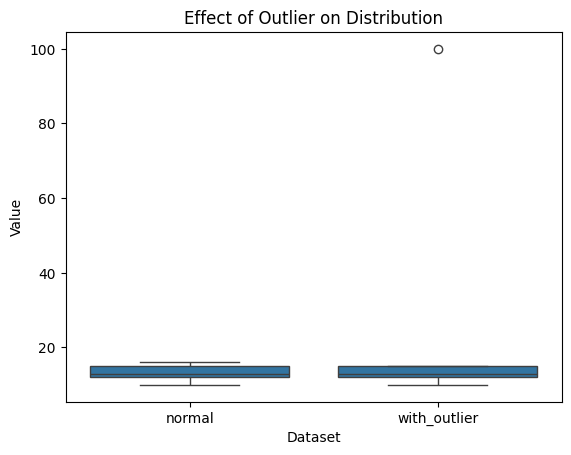

In [26]:
outlier_df = pd.DataFrame({
    "value": list(normal_values) + list(with_outlier),
    "dataset": ["normal"] * len(normal_values) + ["with_outlier"] * len(with_outlier)
})
sns.boxplot(data=outlier_df, x="dataset", y="value")
plt.title("Effect of Outlier on Distribution")
plt.xlabel("Dataset")
plt.ylabel("Value")
plt.show()

## 13. Correlation Example

Use correlation to check whether two numerical columns have a linear relationship.

Important:
- correlation close to `1` means strong positive relationship
- correlation close to `-1` means strong negative relationship
- correlation close to `0` means weak/no linear relationship
- correlation does **not** prove causation


Correlation between study hours and score: 0.9940604735285097


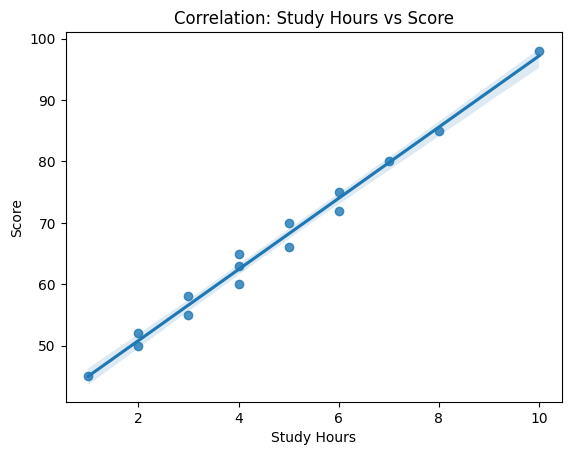

In [ ]:
corr_value = df["study_hours"].corr(df["score"])
print("Correlation between study hours and score:", corr_value)
X   

## 14. Most Practical Terms for Data Science / ML / Finance

Most used in real-world data work:

1. **Mean** — average KPI, average price, average sales.
2. **Median** — better for skewed data like salary and house prices.
3. **Standard deviation** — risk, volatility, spread.
4. **Percentiles / Quantiles** — rankings, thresholds, risk levels.
5. **IQR** — robust spread and outlier detection.
6. **Outliers** — fraud, errors, unusual customers, unusual returns.
7. **Correlation** — relationship exploration.
8. **Skewness** — tells whether mean or median is safer to use.
9. **Distribution** — the first thing to inspect before modeling.
10. **Moving average** — time series, stock prices, sales trends.
